# O2 – Wyznaczanie ogniskowych soczewek i badanie wad soczewek
**Karol Peszek, Grupa B, 20 maja 2026**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DATA_DIR = '.'

## 1. Wczytanie danych

In [2]:
df_chrom  = pd.read_csv(f'{DATA_DIR}/chromatic_aberration.csv')
df_13     = pd.read_csv(f'{DATA_DIR}/lens_1_3.csv')
df_1II3   = pd.read_csv(f'{DATA_DIR}/lens_1_II_3.csv')
df_char   = pd.read_csv(f'{DATA_DIR}/lens_characteristics.csv')
df_obj    = pd.read_csv(f'{DATA_DIR}/object_opsition.csv')
df_spher  = pd.read_csv(f'{DATA_DIR}/spherical_aberration.csv')

x_obj   = df_obj['x_object'].values[0]       # cm
u_x_obj = df_obj['u_x_object'].values[0]     # cm

print(f'Pozycja przedmiotu: x_obj = {x_obj} cm,  u = {u_x_obj} cm')
print(f'Światło biegnie w kierunku malejących x.')
print()
print('Deklarowane zdolności optyczne soczewek (tylko do porównania):')
print(df_char.to_string(index=False))

Pozycja przedmiotu: x_obj = 170.0 cm,  u = 0.1 cm
Światło biegnie w kierunku malejących x.

Deklarowane zdolności optyczne soczewek (tylko do porównania):
lens_id  characteristics
      1               10
     II               -4
      3                6


## 2. Funkcje pomocnicze

In [3]:
def bessel_f(d, l, u_d, u_l):
    """Ogniskowa metodą Bessela: f = (l^2 - d^2) / (4l).
    
    Pochodne cząstkowe:
      df/dl = (l^2 + d^2) / (4l^2)
      df/dd = -d / (2l)
    """
    f = (l**2 - d**2) / (4 * l)
    df_dl = (l**2 + d**2) / (4 * l**2)
    df_dd = -d / (2 * l)
    u_f = np.sqrt((df_dl * u_l)**2 + (df_dd * u_d)**2)
    return f, u_f


def group_bessel(sub_df, x_obj, u_x_obj, x_screen_col='x_screen'):
    """Oblicza ogniskową metodą Bessela dla grupy pomiarów (stała pozycja ekranu).
    
    Niepewność d:
      u_d = sqrt(u_stat^2 + u_sys^2)
      u_stat = std(d_i) / sqrt(n)  (niepewność statystyczna średniej)
      u_sys  = sqrt(u_xl^2 + u_xs^2)  (niepewność systematyczna odczytu pozycji)
    
    Filtr: odrzuca pomiary gdzie x_small < x_screen lub x_large > x_object
    (pozycja soczewki musi leżeć między ekranem a przedmiotem).
    """
    x_screen  = sub_df[x_screen_col].values[0]
    u_x_screen = sub_df['u_x_screen'].values[0]

    # Filtr fizyczny
    mask = (sub_df['x_small'] >= x_screen) & (sub_df['x_large'] <= x_obj)
    sub_df = sub_df[mask]

    x_large = sub_df['x_large'].values
    x_small = sub_df['x_small'].values
    u_xl    = sub_df['u_x_large'].values[0]
    u_xs    = sub_df['u_x_small'].values[0]
    n = len(x_large)

    l   = x_obj - x_screen
    u_l = np.sqrt(u_x_obj**2 + u_x_screen**2)

    d_arr   = x_large - x_small
    d_mean  = np.mean(d_arr)
    u_d_stat = np.std(d_arr, ddof=1) / np.sqrt(n) if n > 1 else 0.0
    u_d_sys  = np.sqrt(u_xl**2 + u_xs**2)
    u_d      = np.sqrt(u_d_stat**2 + u_d_sys**2)

    f, u_f = bessel_f(d_mean, l, u_d, u_l)

    return dict(x_screen=x_screen, l=l, u_l=u_l,
                d_mean=d_mean, u_d=u_d, u_d_stat=u_d_stat,
                f=f, u_f=u_f, n=n, d_arr=d_arr)


def weighted_mean(vals, u_vals):
    """Ważona średnia i jej niepewność."""
    vals  = np.asarray(vals, dtype=float)
    u_vals = np.asarray(u_vals, dtype=float)
    w = 1.0 / u_vals**2
    f_m = np.sum(w * vals) / np.sum(w)
    u_m = 1.0 / np.sqrt(np.sum(w))
    return f_m, u_m


def fmt(val, u, digits=2):
    """Formatuje wynik z niepewnością."""
    return f'({val:.{digits}f} ± {u:.{digits}f}) cm'
def lens_eq_f(a, b, u_a, u_b):
    """Ogniskowa metodą równania soczewki: f = (a * b) / (a + b).
    
    Pochodne cząstkowe:
      df/da = (b / (a + b))^2
      df/db = (a / (a + b))^2
    """
    f = (a * b) / (a + b)
    df_da = (b / (a + b))**2
    df_db = (a / (a + b))**2
    u_f = np.sqrt((df_da * u_a)**2 + (df_db * u_b)**2)
    return f, u_f

def group_lens_eq(sub_df, x_obj, u_x_obj, x_screen_col='x_screen'):
    """Oblicza ogniskową metodą równania soczewki dla grupy pomiarów."""
    x_screen  = sub_df[x_screen_col].values[0]
    u_x_screen = sub_df['u_x_screen'].values[0]
    
    # Tylko powiększony obraz (x_large)
    x_s_arr = sub_df['x_large'].values
    u_xs = sub_df['u_x_large'].values[0]
    
    x_s = np.mean(x_s_arr)
    n = len(x_s_arr)
    u_s_stat = np.std(x_s_arr, ddof=1) / np.sqrt(n) if n > 1 else 0.0
    u_s_total = np.sqrt(u_s_stat**2 + u_xs**2)
    
    a = x_obj - x_s
    u_a = np.sqrt(u_x_obj**2 + u_s_total**2)
    b = x_s - x_screen
    u_b = np.sqrt(u_x_screen**2 + u_s_total**2)
    
    f, u_f = lens_eq_f(a, b, u_a, u_b)
    
    return dict(l=x_obj - x_screen, a=a, u_a=u_a, b=b, u_b=u_b, f=f, u_f=u_f, n=n)

def process_lens_eq(df, label):
    results = []
    for screen_pos, grp in df.groupby('x_screen'):
        r = group_lens_eq(grp, x_obj, u_x_obj)
        results.append(r)
    print(f'\n{label} (równanie soczewki)')
    print(f'{"l [cm]":>8}  {"a [cm]":>10}  {"b [cm]":>10}  {"f [cm]":>24}  {"n":>3}')
    for r in results:
        print(f'{r["l"]:>8.1f}  {r["a"]:>10.3f}  {r["b"]:>10.3f}  '
              f'{fmt(r["f"], r["u_f"]):>24}  {r["n"]:>3}')
    f_arr  = [r['f']   for r in results]
    uf_arr = [r['u_f'] for r in results]
    f_m, u_m = weighted_mean(f_arr, uf_arr)
    print(f'  Średnia ważona: f = {fmt(f_m, u_m)}')
    return results, f_m, u_m



## 3. Układy soczewek skupiających – metoda Bessela

Ogniskowa wyznaczana ze wzoru:
$$f = \frac{l^2 - d^2}{4l}$$
gdzie $l = x_{\mathrm{obiekt}} - x_{\mathrm{ekran}}$, $d = x_{\mathrm{dużyobraz}} - x_{\mathrm{małyobraz}}$.

In [4]:
def process_system(df, label):
    results = []
    for x_s, grp in df.groupby('x_screen', sort=True):
        r = group_bessel(grp, x_obj, u_x_obj)
        results.append(r)
    print(f'\n{label}')
    print(f'{"l [cm]":>8}  {"d_śr [cm]":>10}  {"f [cm]":>24}  {"n":>3}')
    for r in results:
        print(f'{r["l"]:>8.1f}  {r["d_mean"]:>10.3f}  '
              f'{fmt(r["f"], r["u_f"]):>24}  {r["n"]:>3}')
    f_arr  = [r['f']   for r in results]
    uf_arr = [r['u_f'] for r in results]
    f_m, u_m = weighted_mean(f_arr, uf_arr)
    print(f'  Średnia ważona: f = {fmt(f_m, u_m)}')
    return results, f_m, u_m


res_13,   f_13,   u_f_13   = process_system(df_13,   'Układ 1+3')
res_1II3, f_1II3, u_f_1II3 = process_system(df_1II3, 'Układ 1+II+3')
res_13_eq, f_13_eq, u_f_13_eq = process_lens_eq(df_13, 'Układ 1+3')


Układ 1+3
  l [cm]   d_śr [cm]                    f [cm]    n
    60.0      42.900          (7.33 ± 0.11) cm    8
    50.0      32.125          (7.34 ± 0.10) cm    8
    40.0      21.350          (7.15 ± 0.09) cm    8
  Średnia ważona: f = (7.26 ± 0.06) cm

Układ 1+II+3
  l [cm]   d_śr [cm]                    f [cm]    n
    60.0      39.925          (8.36 ± 0.11) cm    8
    50.0      28.488          (8.44 ± 0.10) cm    8
    40.0      16.525          (8.29 ± 0.07) cm    8
  Średnia ważona: f = (8.35 ± 0.05) cm

Układ 1+3 (równanie soczewki)
  l [cm]      a [cm]      b [cm]                    f [cm]    n
    60.0       8.675      51.325          (7.42 ± 0.17) cm    8
    50.0       8.963      41.037          (7.36 ± 0.16) cm    8
    40.0       9.463      30.537          (7.22 ± 0.14) cm    8
  Średnia ważona: f = (7.32 ± 0.09) cm


## 4. Ogniskowa soczewki rozpraszającej II

Z wzoru na ogniskową układu stykających się soczewek:
$$\frac{1}{f_{\mathrm{II}}} = \frac{1}{f_{1+\mathrm{II}+3}} - \frac{1}{f_{1+3}}$$

Propagacja niepewności:
$$u_{f_{\mathrm{II}}} = f_{\mathrm{II}}^2 \sqrt{\left(\frac{u_{f_{1+\mathrm{II}+3}}}{f_{1+\mathrm{II}+3}^2}\right)^2 + \left(\frac{u_{f_{1+3}}}{f_{1+3}^2}\right)^2}$$

In [5]:
D_1II3 = 1.0 / f_1II3
D_13   = 1.0 / f_13
D_II   = D_1II3 - D_13
f_II   = 1.0 / D_II

u_D_1II3 = u_f_1II3 / f_1II3**2
u_D_13   = u_f_13   / f_13**2
u_D_II   = np.sqrt(u_D_1II3**2 + u_D_13**2)
u_f_II   = abs(f_II**2) * u_D_II

print('=== Wyniki układów soczewek ===')
print(f'f_(1+3)     = {fmt(f_13, u_f_13)}')
print(f'f_(1+II+3)  = {fmt(f_1II3, u_f_1II3)}')
print(f'f_II        = {fmt(f_II, u_f_II)}')
print()

# Deklarowane (tylko do porównania)
# lens_id bywa mieszanego typu – konwertujemy klucze do str
D_dec = {str(row['lens_id']): row['characteristics'] for _, row in df_char.iterrows()}
f13_dec   = 100.0 / (D_dec['1'] + D_dec['3'])                # cm
f1II3_dec = 100.0 / (D_dec['1'] + D_dec['II'] + D_dec['3'])  # cm
fII_dec   = 100.0 / D_dec['II']                              # cm

print('=== Porównanie z wartościami deklarowanymi ===')
print(f'f_(1+3)     dek. = {f13_dec:.3f} cm,   exp. = {fmt(f_13, u_f_13)}')
print(f'f_(1+II+3)  dek. = {f1II3_dec:.3f} cm,   exp. = {fmt(f_1II3, u_f_1II3)}')
print(f'f_II        dek. = {fII_dec:.2f} cm,  exp. = {fmt(f_II, u_f_II)}')

=== Wyniki układów soczewek ===
f_(1+3)     = (7.26 ± 0.06) cm
f_(1+II+3)  = (8.35 ± 0.05) cm
f_II        = (-55.39 ± 4.08) cm

=== Porównanie z wartościami deklarowanymi ===
f_(1+3)     dek. = 6.250 cm,   exp. = (7.26 ± 0.06) cm
f_(1+II+3)  dek. = 8.333 cm,   exp. = (8.35 ± 0.05) cm
f_II        dek. = -25.00 cm,  exp. = (-55.39 ± 4.08) cm


Tablicowa f_{1+3} = 6.25 cm
Tablicowa f_{1+II+3} = 8.33 cm
Tablicowa f_{II} = -25.00 cm
Eksperymentalna f_{II} = (-55.39 ± 4.08) cm


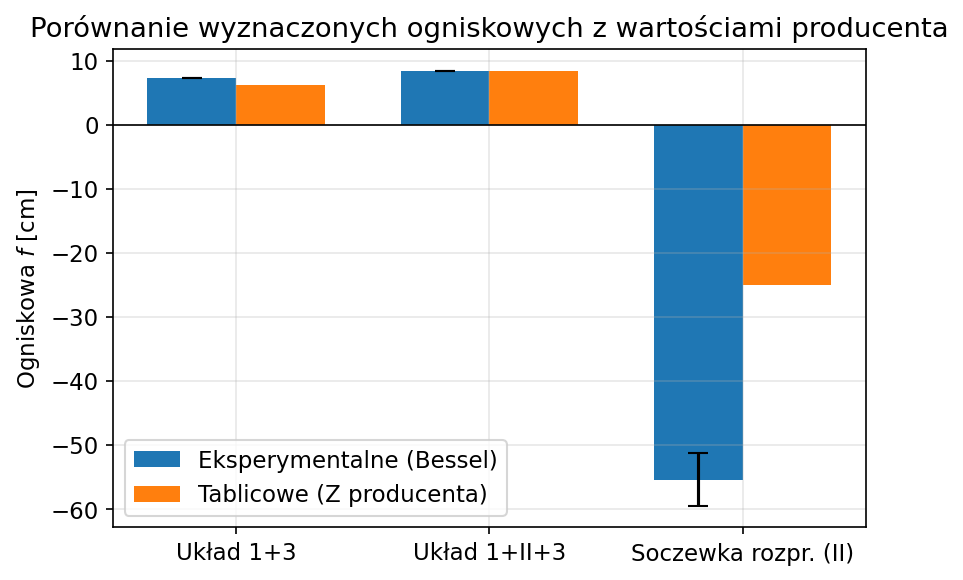

In [6]:
# --- Porównanie wyników z wartościami tablicowymi ---
# Producent podaje: soczewka 1 (10 D), soczewka 3 (6 D), soczewka II (-4 D).
f_1_tab = 100.0 / 10.0      # 10.0 cm
f_3_tab = 100.0 / 6.0       # 16.67 cm
f_II_tab = 100.0 / -4.0     # -25.0 cm

f_13_tab = 100.0 / (10.0 + 6.0)         # 6.25 cm
f_1II3_tab = 100.0 / (10.0 - 4.0 + 6.0) # 8.33 cm

print(f"Tablicowa f_{{1+3}} = {f_13_tab:.2f} cm")
print(f"Tablicowa f_{{1+II+3}} = {f_1II3_tab:.2f} cm")
print(f"Tablicowa f_{{II}} = {f_II_tab:.2f} cm")

# Eksperymentalna f_II:
# 1/f_II = 1/f_1II3 - 1/f_13 => f_II = (f_1II3 * f_13) / (f_13 - f_1II3)
f_II_exp = (f_1II3 * f_13) / (f_13 - f_1II3)
u_f_II_exp = np.sqrt(((f_13**2 / (f_13 - f_1II3)**2) * u_f_1II3)**2 + ((-f_1II3**2 / (f_13 - f_1II3)**2) * u_f_13)**2)

print(f"Eksperymentalna f_{{II}} = {fmt(f_II_exp, u_f_II_exp)}")

labels = ['Układ 1+3', 'Układ 1+II+3', 'Soczewka rozpr. (II)']
f_exp = [f_13, f_1II3, f_II_exp]
u_exp = [u_f_13, u_f_1II3, u_f_II_exp]
f_tab = [f_13_tab, f_1II3_tab, f_II_tab]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, f_exp, width, yerr=u_exp, capsize=5, label='Eksperymentalne (Bessel)', color='C0')
ax.bar(x + width/2, f_tab, width, label='Tablicowe (Z producenta)', color='C1')

ax.set_ylabel('Ogniskowa $f$ [cm]')
ax.set_title('Porównanie wyznaczonych ogniskowych z wartościami producenta')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/plot_comparison.pdf')
plt.show()



## 5. Aberracja sferyczna

Miarą aberracji sferycznej jest różnica ogniskowych dla promieni przyosiowych (paraxial) i brzegowych (peripheral):
$$\Delta f_{\mathrm{sf}} = f_{\mathrm{par}} - f_{\mathrm{per}}$$

In [7]:
spher_by_l = {}
for (x_s, diaph), grp in df_spher.groupby(['x_screen', 'diaphragm'], sort=True):
    r = group_bessel(grp, x_obj, u_x_obj)
    l_val = r['l']
    if l_val not in spher_by_l:
        spher_by_l[l_val] = {}
    spher_by_l[l_val][diaph] = r

print('Aberracja sferyczna')
print(f'{"l [cm]":>8}  {"f_par [cm]":>24}  {"f_per [cm]":>24}  {"Δf [cm]":>16}')

aberr_sf = []
for l_val in sorted(spher_by_l):
    r_par = spher_by_l[l_val]['paraxial']
    r_per = spher_by_l[l_val]['peripheral']
    df_sf  = r_par['f'] - r_per['f']
    u_df   = np.sqrt(r_par['u_f']**2 + r_per['u_f']**2)
    aberr_sf.append(dict(l=l_val,
                         f_par=r_par['f'], u_par=r_par['u_f'],
                         f_per=r_per['f'], u_per=r_per['u_f'],
                         delta=df_sf, u_delta=u_df))
    print(f'{l_val:>8.1f}  {fmt(r_par["f"], r_par["u_f"]):>24}  '
          f'{fmt(r_per["f"], r_per["u_f"]):>24}  {fmt(df_sf, u_df):>16}')

delta_sf_arr  = np.array([x['delta']   for x in aberr_sf])
u_delta_sf    = np.array([x['u_delta'] for x in aberr_sf])
delta_sf_mean, u_delta_sf_mean = weighted_mean(delta_sf_arr, u_delta_sf)
print(f'\nŚrednia aberracja sferyczna: Δf = {fmt(delta_sf_mean, u_delta_sf_mean)}')

Aberracja sferyczna
  l [cm]                f_par [cm]                f_per [cm]           Δf [cm]
   100.0         (20.22 ± 0.17) cm         (17.24 ± 0.21) cm  (2.98 ± 0.27) cm
   120.0         (20.39 ± 0.21) cm         (17.13 ± 0.24) cm  (3.27 ± 0.32) cm

Średnia aberracja sferyczna: Δf = (3.10 ± 0.21) cm


## 6. Aberracja chromatyczna

Miarą aberracji chromatycznej jest różnica ogniskowych dla światła czerwonego i niebieskiego:
$$\Delta f_{\mathrm{ch}} = f_{\mathrm{red}} - f_{\mathrm{blue}}$$

In [8]:
chrom_by_l = {}
for (x_s, color), grp in df_chrom.groupby(['x_screen', 'color'], sort=True):
    r = group_bessel(grp, x_obj, u_x_obj)
    l_val = r['l']
    if l_val not in chrom_by_l:
        chrom_by_l[l_val] = {}
    chrom_by_l[l_val][color] = r
    if r['n'] < len(grp):  # informacja o odrzuconych punktach
        n_odrzucone = len(grp) - r['n']
        print(f'INFO: Odrzucono {n_odrzucone} punkt(y) dla l={l_val} cm, kolor={color} '
              f'(x_small poza zakresem [x_screen, x_obj]).')

print()
print('Aberracja chromatyczna')
print(f'{"l [cm]":>8}  {"f_red [cm]":>24}  {"f_blue [cm]":>24}  {"Δf [cm]":>16}')

aberr_ch = []
for l_val in sorted(chrom_by_l):
    if 'red' not in chrom_by_l[l_val] or 'blue' not in chrom_by_l[l_val]:
        continue
    r_red  = chrom_by_l[l_val]['red']
    r_blue = chrom_by_l[l_val]['blue']
    df_ch  = r_red['f'] - r_blue['f']
    u_df   = np.sqrt(r_red['u_f']**2 + r_blue['u_f']**2)
    aberr_ch.append(dict(l=l_val,
                         f_red=r_red['f'],  u_red=r_red['u_f'],
                         f_blue=r_blue['f'], u_blue=r_blue['u_f'],
                         delta=df_ch, u_delta=u_df))
    print(f'{l_val:>8.1f}  {fmt(r_red["f"], r_red["u_f"]):>24}  '
          f'{fmt(r_blue["f"], r_blue["u_f"]):>24}  {fmt(df_ch, u_df):>16}')

delta_ch_arr = np.array([x['delta']   for x in aberr_ch])
u_delta_ch   = np.array([x['u_delta'] for x in aberr_ch])
delta_ch_mean, u_delta_ch_mean = weighted_mean(delta_ch_arr, u_delta_ch)
print(f'\nŚrednia aberracja chromatyczna: Δf = {fmt(delta_ch_mean, u_delta_ch_mean)}')


Aberracja chromatyczna
  l [cm]                f_red [cm]               f_blue [cm]           Δf [cm]
   100.0         (19.31 ± 0.18) cm         (18.93 ± 0.19) cm  (0.38 ± 0.26) cm
   120.0         (19.40 ± 0.22) cm         (18.96 ± 0.22) cm  (0.44 ± 0.31) cm

Średnia aberracja chromatyczna: Δf = (0.40 ± 0.20) cm


## 7. Wykresy

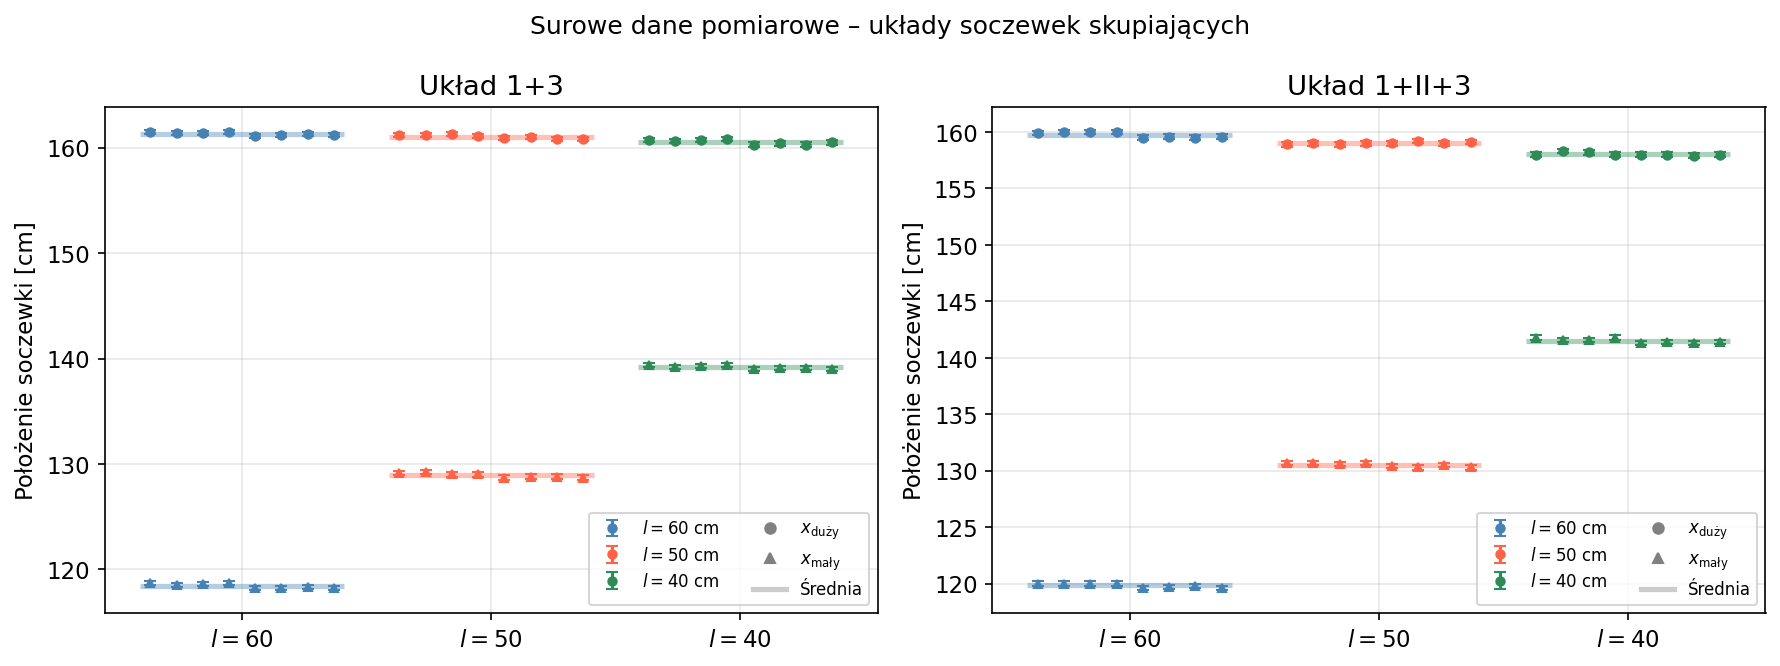

Zapisano: plot_raw_systems.pdf


In [9]:

# ── Wykresy surowych danych: układy soczewek skupiających ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

datasets = [(df_13, 'Układ 1+3', axes[0]),
            (df_1II3, 'Układ 1+II+3', axes[1])]
palette = ['steelblue', 'tomato', 'seagreen']
margin  = 0.4

for df_sys, title, ax in datasets:
    offset = 0
    ticks, tick_labels = [], []
    for idx, (x_s, grp) in enumerate(df_sys.groupby('x_screen', sort=True)):
        l_val = x_obj - x_s
        grp   = grp.reset_index(drop=True)
        n     = len(grp)
        xs    = np.arange(n) + offset
        col   = palette[idx]

        # punkty – w pełni nieprzezroczyste, na wierzchu
        ax.errorbar(xs, grp['x_large'], yerr=grp['u_x_large'],
                    marker='o', ls='', color=col, capsize=3, ms=4, zorder=3,
                    label=f'$l={l_val:.0f}$ cm')
        ax.errorbar(xs, grp['x_small'], yerr=grp['u_x_small'],
                    marker='^', ls='', color=col, capsize=3, ms=4, zorder=3)

        # linie średnich – pełne, półprzezroczyste, pod punktami
        x_lo, x_hi = xs[0] - margin, xs[-1] + margin
        ax.hlines(grp['x_large'].mean(), x_lo, x_hi,
                  colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)
        ax.hlines(grp['x_small'].mean(), x_lo, x_hi,
                  colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)

        ticks.append(offset + n / 2 - 0.5)
        tick_labels.append(f'$l={l_val:.0f}$')
        offset += n + 1.5

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel('Położenie soczewki [cm]')
    ax.set_title(title)

    from matplotlib.lines import Line2D
    sym_els = [Line2D([0],[0], marker='o', color='gray', ms=5, ls='none',
                      label='$x_{\\mathrm{duży}}$'),
               Line2D([0],[0], marker='^', color='gray', ms=5, ls='none',
                      label='$x_{\\mathrm{mały}}$'),
               Line2D([0],[0], color='gray', ls='-', lw=2.5, alpha=0.4,
                      label='Średnia')]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + sym_els, labels + [e.get_label() for e in sym_els],
              fontsize=8, ncol=2)

fig.suptitle('Surowe dane pomiarowe – układy soczewek skupiających', fontsize=12)
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_raw_systems.pdf')
plt.show()
print('Zapisano: plot_raw_systems.pdf')


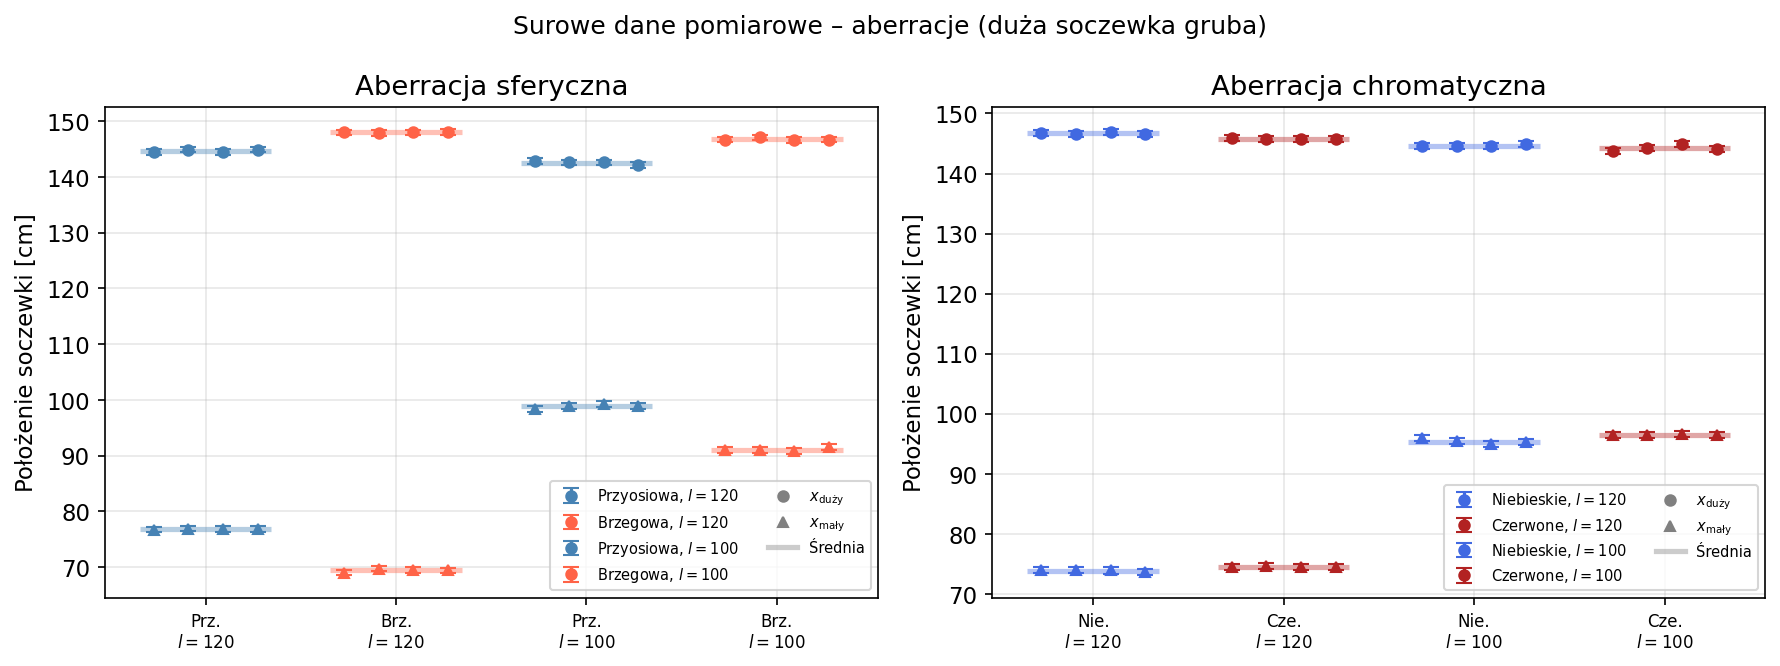

Zapisano: plot_raw_aberrations.pdf


In [10]:

# ── Wykresy surowych danych: aberracje ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
margin = 0.4

# ── Panel lewy: aberracja sferyczna ─────────────────────────────────────────
ax = axes[0]
palette_s = {'paraxial': 'steelblue', 'peripheral': 'tomato'}
label_s   = {'paraxial': 'Przyosiowa', 'peripheral': 'Brzegowa'}
offset = 0
ticks, tick_labels = [], []
for (x_s, diaph), grp in df_spher.groupby(['x_screen', 'diaphragm'], sort=True):
    l_val = x_obj - x_s
    grp   = grp.reset_index(drop=True)
    n     = len(grp)
    xs    = np.arange(n) + offset
    col   = palette_s[diaph]

    ax.errorbar(xs, grp['x_large'], yerr=grp['u_x_large'],
                marker='o', ls='', color=col, capsize=4, ms=5, zorder=3,
                label=f'{label_s[diaph]}, $l={l_val:.0f}$')
    ax.errorbar(xs, grp['x_small'], yerr=grp['u_x_small'],
                marker='^', ls='', color=col, capsize=4, ms=5, zorder=3)

    x_lo, x_hi = xs[0] - margin, xs[-1] + margin
    ax.hlines(grp['x_large'].mean(), x_lo, x_hi,
              colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)
    ax.hlines(grp['x_small'].mean(), x_lo, x_hi,
              colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)

    ticks.append(offset + n / 2 - 0.5)
    tick_labels.append(f'{label_s[diaph][:3]}.\n$l={l_val:.0f}$')
    offset += n + 1.5

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel('Położenie soczewki [cm]')
ax.set_title('Aberracja sferyczna')

# ── Panel prawy: aberracja chromatyczna ─────────────────────────────────────
ax2 = axes[1]
palette_c = {'red': 'firebrick', 'blue': 'royalblue'}
label_c   = {'red': 'Czerwone', 'blue': 'Niebieskie'}
offset = 0
ticks, tick_labels = [], []
for (x_s, color), grp in df_chrom.groupby(['x_screen', 'color'], sort=True):
    l_val = x_obj - x_s
    grp   = grp[(grp['x_small'] >= x_s) & (grp['x_large'] <= x_obj)].reset_index(drop=True)
    if len(grp) == 0:
        continue
    n   = len(grp)
    xs  = np.arange(n) + offset
    col = palette_c[color]

    ax2.errorbar(xs, grp['x_large'], yerr=grp['u_x_large'],
                 marker='o', ls='', color=col, capsize=4, ms=5, zorder=3,
                 label=f'{label_c[color]}, $l={l_val:.0f}$')
    ax2.errorbar(xs, grp['x_small'], yerr=grp['u_x_small'],
                 marker='^', ls='', color=col, capsize=4, ms=5, zorder=3)

    x_lo, x_hi = xs[0] - margin, xs[-1] + margin
    ax2.hlines(grp['x_large'].mean(), x_lo, x_hi,
               colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)
    ax2.hlines(grp['x_small'].mean(), x_lo, x_hi,
               colors=col, linestyles='-', linewidth=2.5, alpha=0.4, zorder=2)

    ticks.append(offset + n / 2 - 0.5)
    tick_labels.append(f'{label_c[color][:3]}.\n$l={l_val:.0f}$')
    offset += n + 1.5

ax2.set_xticks(ticks)
ax2.set_xticklabels(tick_labels, fontsize=8)
ax2.set_ylabel('Położenie soczewki [cm]')
ax2.set_title('Aberracja chromatyczna')

# ── Legenda wspólna ─────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
sym_els = [Line2D([0],[0], marker='o', color='gray', ms=5, ls='none',
                  label='$x_{\\mathrm{duży}}$'),
           Line2D([0],[0], marker='^', color='gray', ms=5, ls='none',
                  label='$x_{\\mathrm{mały}}$'),
           Line2D([0],[0], color='gray', ls='-', lw=2.5, alpha=0.4,
                  label='Średnia')]
for a in axes:
    handles, labels = a.get_legend_handles_labels()
    a.legend(handles + sym_els, labels + [e.get_label() for e in sym_els],
             fontsize=7, ncol=2)

fig.suptitle('Surowe dane pomiarowe – aberracje (duża soczewka gruba)', fontsize=12)
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_raw_aberrations.pdf')
plt.show()
print('Zapisano: plot_raw_aberrations.pdf')


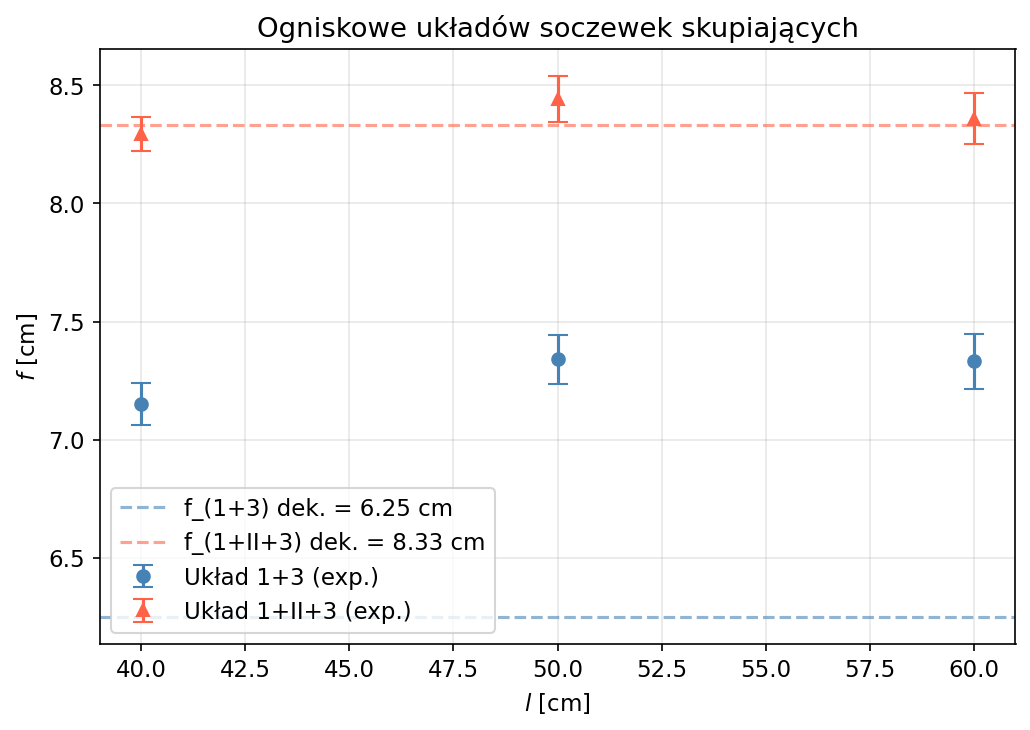

Zapisano: plot_lens_systems.pdf


In [11]:
# ── Wykres 1: Układy soczewek skupiających ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

l_13   = [r['l'] for r in res_13]
f_13s  = [r['f'] for r in res_13]
uf_13s = [r['u_f'] for r in res_13]

l_1II3   = [r['l'] for r in res_1II3]
f_1II3s  = [r['f'] for r in res_1II3]
uf_1II3s = [r['u_f'] for r in res_1II3]

ax.errorbar(l_13, f_13s, yerr=uf_13s,
            marker='o', ls='', color='steelblue', capsize=5, label='Układ 1+3 (exp.)')
ax.errorbar(l_1II3, f_1II3s, yerr=uf_1II3s,
            marker='^', ls='', color='tomato', capsize=5, label='Układ 1+II+3 (exp.)')

ax.axhline(f13_dec,   color='steelblue', ls='--', alpha=0.6, label=f'f_(1+3) dek. = {f13_dec:.2f} cm')
ax.axhline(f1II3_dec, color='tomato',    ls='--', alpha=0.6, label=f'f_(1+II+3) dek. = {f1II3_dec:.2f} cm')

ax.set_xlabel('$l$ [cm]')
ax.set_ylabel('$f$ [cm]')
ax.set_title('Ogniskowe układów soczewek skupiających')
ax.legend()
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_lens_systems.pdf')
plt.show()
print('Zapisano: plot_lens_systems.pdf')


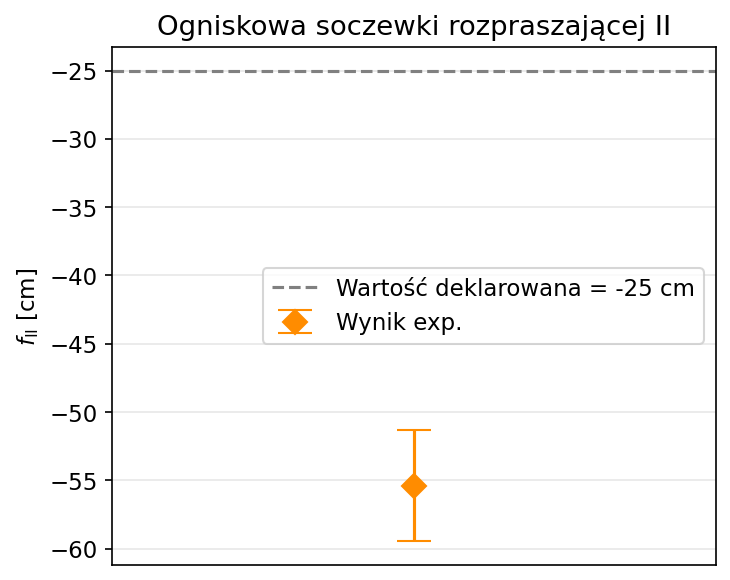

Zapisano: plot_diverging_lens.pdf


In [12]:
# ── Wykres 2: Soczewka rozpraszająca II ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))

ax.errorbar([0], [f_II], yerr=[u_f_II],
            marker='D', ls='', color='darkorange', capsize=8, markersize=8, label='Wynik exp.')
ax.axhline(fII_dec, color='gray', ls='--', label=f'Wartość deklarowana = {fII_dec:.0f} cm')

ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel('$f_{\\mathrm{II}}$ [cm]')
ax.set_title('Ogniskowa soczewki rozpraszającej II')
ax.legend()
fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_diverging_lens.pdf')
plt.show()
print('Zapisano: plot_diverging_lens.pdf')


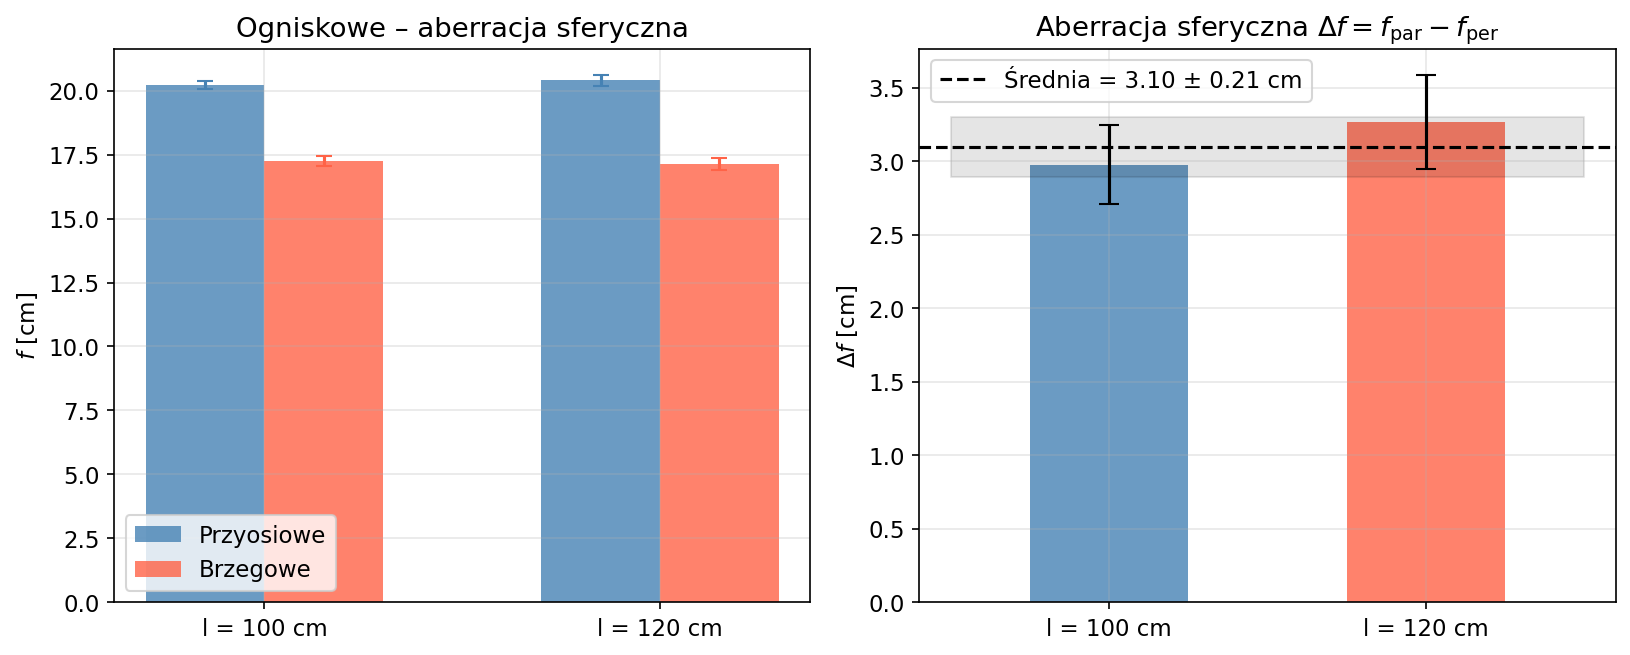

Zapisano: plot_spherical_aberration.pdf


In [13]:
# ── Wykres 3: Aberracja sferyczna ────────────────────────────────────────────
l_vals_sf = [x['l'] for x in aberr_sf]
n_sf = len(l_vals_sf)
x_pos = np.arange(n_sf)
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel lewy: surowe ogniskowe
ax = axes[0]
ax.bar(x_pos - w/2, [x['f_par'] for x in aberr_sf],
       width=w, color='steelblue', alpha=0.8, label='Przyosiowe')
ax.bar(x_pos + w/2, [x['f_per'] for x in aberr_sf],
       width=w, color='tomato',    alpha=0.8, label='Brzegowe')
ax.errorbar(x_pos - w/2, [x['f_par'] for x in aberr_sf],
            yerr=[x['u_par'] for x in aberr_sf],
            fmt='none', color='steelblue', capsize=4)
ax.errorbar(x_pos + w/2, [x['f_per'] for x in aberr_sf],
            yerr=[x['u_per'] for x in aberr_sf],
            fmt='none', color='tomato', capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'l = {lv:.0f} cm' for lv in l_vals_sf])
ax.set_ylabel('$f$ [cm]')
ax.set_title('Ogniskowe – aberracja sferyczna')
ax.legend()

# Panel prawy: aberracja Δf
ax2 = axes[1]
colors = ['steelblue', 'tomato']
bars = ax2.bar(x_pos, [x['delta'] for x in aberr_sf],
               width=0.5, color=colors[:n_sf], alpha=0.8)
ax2.errorbar(x_pos, [x['delta'] for x in aberr_sf],
             yerr=[x['u_delta'] for x in aberr_sf],
             fmt='none', color='black', capsize=5)
ax2.axhline(delta_sf_mean, color='black', ls='--',
            label=f'Średnia = {delta_sf_mean:.2f} ± {u_delta_sf_mean:.2f} cm')
ax2.fill_between([-0.5, n_sf-0.5],
                 delta_sf_mean - u_delta_sf_mean,
                 delta_sf_mean + u_delta_sf_mean,
                 color='black', alpha=0.1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'l = {lv:.0f} cm' for lv in l_vals_sf])
ax2.set_ylabel('$\\Delta f$ [cm]')
ax2.set_title('Aberracja sferyczna $\\Delta f = f_{\\mathrm{par}} - f_{\\mathrm{per}}$')
ax2.legend()

fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_spherical_aberration.pdf')
plt.show()
print('Zapisano: plot_spherical_aberration.pdf')

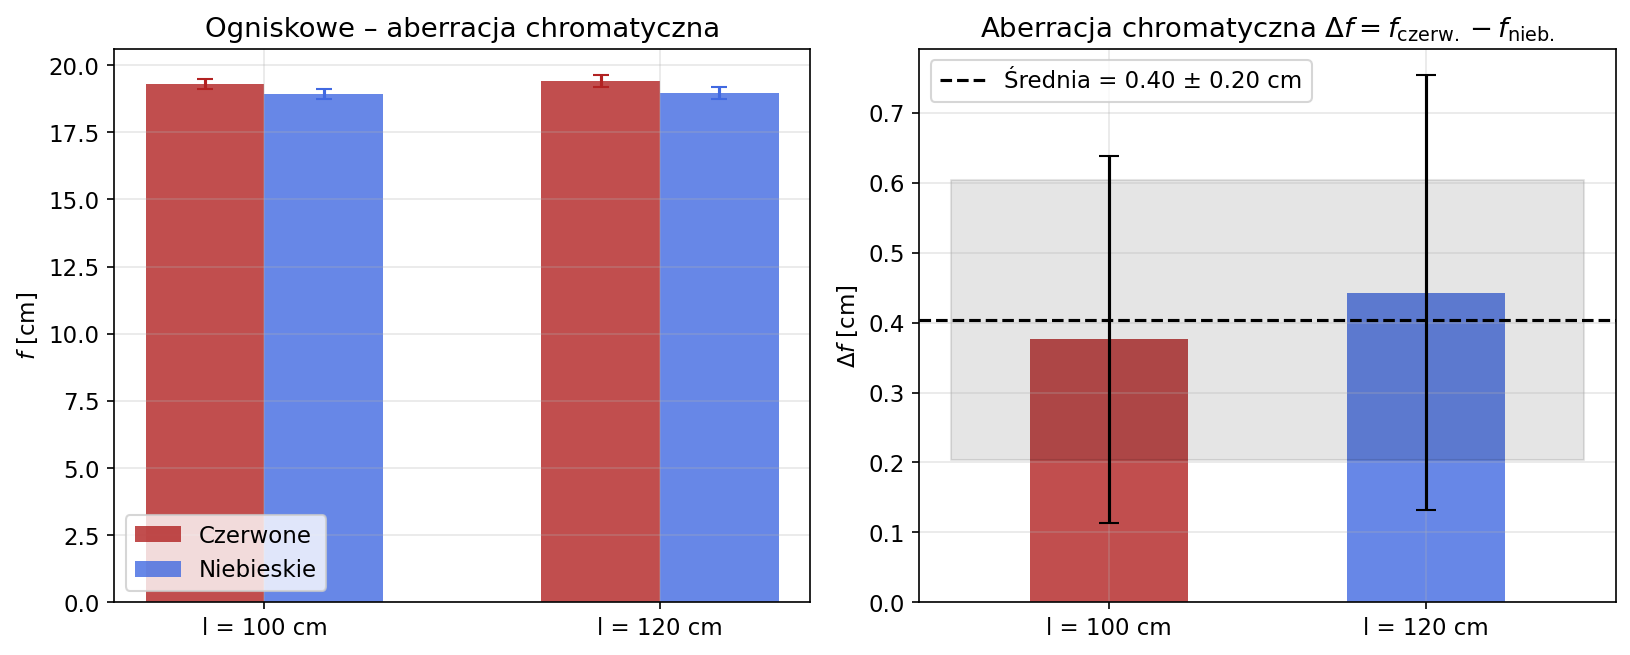

Zapisano: plot_chromatic_aberration.pdf


In [14]:
# ── Wykres 4: Aberracja chromatyczna ─────────────────────────────────────────
l_vals_ch = [x['l'] for x in aberr_ch]
n_ch = len(l_vals_ch)
x_pos = np.arange(n_ch)
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel lewy: surowe ogniskowe
ax = axes[0]
ax.bar(x_pos - w/2, [x['f_red']  for x in aberr_ch],
       width=w, color='firebrick', alpha=0.8, label='Czerwone')
ax.bar(x_pos + w/2, [x['f_blue'] for x in aberr_ch],
       width=w, color='royalblue', alpha=0.8, label='Niebieskie')
ax.errorbar(x_pos - w/2, [x['f_red']  for x in aberr_ch],
            yerr=[x['u_red']  for x in aberr_ch],
            fmt='none', color='firebrick', capsize=4)
ax.errorbar(x_pos + w/2, [x['f_blue'] for x in aberr_ch],
            yerr=[x['u_blue'] for x in aberr_ch],
            fmt='none', color='royalblue', capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'l = {lv:.0f} cm' for lv in l_vals_ch])
ax.set_ylabel('$f$ [cm]')
ax.set_title('Ogniskowe – aberracja chromatyczna')
ax.legend()

# Panel prawy: aberracja Δf
ax2 = axes[1]
bar_colors = ['firebrick', 'royalblue']
ax2.bar(x_pos, [x['delta'] for x in aberr_ch],
        width=0.5, color=bar_colors[:n_ch], alpha=0.8)
ax2.errorbar(x_pos, [x['delta'] for x in aberr_ch],
             yerr=[x['u_delta'] for x in aberr_ch],
             fmt='none', color='black', capsize=5)
ax2.axhline(delta_ch_mean, color='black', ls='--',
            label=f'Średnia = {delta_ch_mean:.2f} ± {u_delta_ch_mean:.2f} cm')
ax2.fill_between([-0.5, n_ch-0.5],
                 delta_ch_mean - u_delta_ch_mean,
                 delta_ch_mean + u_delta_ch_mean,
                 color='black', alpha=0.1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'l = {lv:.0f} cm' for lv in l_vals_ch])
ax2.set_ylabel('$\\Delta f$ [cm]')
ax2.set_title('Aberracja chromatyczna $\\Delta f = f_{\\mathrm{czerw.}} - f_{\\mathrm{nieb.}}$')
ax2.legend()

fig.tight_layout()
fig.savefig(f'{DATA_DIR}/plot_chromatic_aberration.pdf')
plt.show()
print('Zapisano: plot_chromatic_aberration.pdf')

## 8. Podsumowanie wyników

In [15]:
print('=' * 60)
print('PODSUMOWANIE WYNIKÓW')
print('=' * 60)

print('\n--- Układy soczewek skupiających ---')
print(f'  f_(1+3)         = {fmt(f_13, u_f_13)}')
print(f'  f_(1+3)  dek.   = {f13_dec:.3f} cm')
print(f'  f_(1+II+3)      = {fmt(f_1II3, u_f_1II3)}')
print(f'  f_(1+II+3) dek. = {f1II3_dec:.3f} cm')

print('\n--- Soczewka rozpraszająca II ---')
print(f'  f_II            = {fmt(f_II, u_f_II)}')
print(f'  D_II            = ({100/f_II:.2f} ± {u_f_II/f_II**2*100:.2f}) D')
print(f'  f_II dek.       = {fII_dec:.1f} cm  (D = {D_dec["II"]} D)')

print('\n--- Aberracja sferyczna ---')
for x in aberr_sf:
    print(f'  l = {x["l"]:.0f} cm:  Δf = {fmt(x["delta"], x["u_delta"])}')
print(f'  Średnia:  Δf = {fmt(delta_sf_mean, u_delta_sf_mean)}')

print('\n--- Aberracja chromatyczna (czerwone – niebieskie) ---')
for x in aberr_ch:
    print(f'  l = {x["l"]:.0f} cm:  Δf = {fmt(x["delta"], x["u_delta"])}')
print(f'  Średnia:  Δf = {fmt(delta_ch_mean, u_delta_ch_mean)}')
print('=' * 60)

PODSUMOWANIE WYNIKÓW

--- Układy soczewek skupiających ---
  f_(1+3)         = (7.26 ± 0.06) cm
  f_(1+3)  dek.   = 6.250 cm
  f_(1+II+3)      = (8.35 ± 0.05) cm
  f_(1+II+3) dek. = 8.333 cm

--- Soczewka rozpraszająca II ---
  f_II            = (-55.39 ± 4.08) cm
  D_II            = (-1.81 ± 0.13) D
  f_II dek.       = -25.0 cm  (D = -4 D)

--- Aberracja sferyczna ---
  l = 100 cm:  Δf = (2.98 ± 0.27) cm
  l = 120 cm:  Δf = (3.27 ± 0.32) cm
  Średnia:  Δf = (3.10 ± 0.21) cm

--- Aberracja chromatyczna (czerwone – niebieskie) ---
  l = 100 cm:  Δf = (0.38 ± 0.26) cm
  l = 120 cm:  Δf = (0.44 ± 0.31) cm
  Średnia:  Δf = (0.40 ± 0.20) cm
